## Final Project - eCommerce Behavior Data from Multi Category Store
### by Izzan Muhammad Fa'iz

Notebook ini untuk melakukan proses Data Understanding, Data Cleaning, Feature Engineering, EDA, dan lain sebagainya.

## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy import stats
from statsmodels.tsa.holtwinters import ExponentialSmoothing

## Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\MSI1\Downloads\2019-Oct.csv\eCommerce behavior-Oct.csv")
dfraw = df
dfraw.head(20)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d
5,2019-10-01 00:00:05 UTC,view,1480613,2053013561092866779,computers.desktop,pulser,908.62,512742880,0d0d91c2-c9c2-4e81-90a5-86594dec0db9
6,2019-10-01 00:00:08 UTC,view,17300353,2053013553853497655,NaN,creed,380.96,555447699,4fe811e9-91de-46da-90c3-bbd87ed3a65d
7,2019-10-01 00:00:08 UTC,view,31500053,2053013558031024687,NaN,luminarc,41.16,550978835,6280d577-25c8-4147-99a7-abc6048498d6
8,2019-10-01 00:00:10 UTC,view,28719074,2053013565480109009,apparel.shoes.keds,baden,102.71,520571932,ac1cd4e5-a3ce-4224-a2d7-ff660a105880
9,2019-10-01 00:00:11 UTC,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.01,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb


## Data Structure Check
Tahap ini bertujuan untuk memahami struktur dasar dataset sebelum dilakukan proses pembersihan data (data cleaning). Analisis ini meliputi ukuran dataset, nama kolom, tipe data, statistik deskriptif, serta pemeriksaan konsistensi struktur data.

Melalui tahap ini dapat diketahui apakah terdapat ketidaksesuaian struktur data yang perlu diperbaiki sebelum masuk ke proses analisis lebih lanjut.

In [3]:
# Mengetahui jumlah baris dan kolom dari dataset

print("="*50)
print("Dataset Shape")
print("="*50)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Dataset Shape
Rows    : 42,448,764
Columns : 9


In [4]:
# Identifikasi seluruh nama kolom beserta urutannya untuk 
# memahami atribut yang tersedia pada dataset.

columns = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values
})

dtype_summary = (
    df.dtypes
      .value_counts()
      .rename_axis("Data Type")
      .reset_index(name="Total Columns")
)
display(columns)
display(dtype_summary)

,Column Name,Data Type
0,event_time,str
1,event_type,str
2,product_id,int64
3,category_id,int64
4,category_code,str
5,brand,str
6,price,float64
7,user_id,int64
8,user_session,str


,Data Type,Total Columns
0,str,5
1,int64,3
2,float64,1


In [5]:
# Statistik deskriptif dari dataset
# Numerik

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
product_id,42448764.0,1.054993e+07,1.188191e+07,1.000978e+06,1.005157e+06,5.000470e+06,1.600030e+07,6.050001e+07
category_id,42448764.0,2.057404e+18,1.843926e+16,2.053014e+18,2.053014e+18,2.053014e+18,2.053014e+18,2.175420e+18
price,42448764.0,2.903237e+02,3.582692e+02,0.000000e+00,6.598000e+01,1.629300e+02,3.585700e+02,2.574070e+03
user_id,42448764.0,5.335371e+08,1.852374e+07,3.386938e+07,5.159043e+08,5.296965e+08,5.515788e+08,5.662809e+08


In [6]:
# Statistik deskriptif dari dataset
# Kategorikal

display(df.describe(include="object").T)

C:\Users\MSI1\AppData\Local\Temp\ipykernel_24168\3182017980.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object").T)


,count,unique,top,freq
event_time,42448764,2621538,2019-10-15 08:52:00 UTC,116
event_type,42448764,3,view,40779399
category_code,28933155,126,electronics.smartphone,11507231
brand,36331684,3444,samsung,5282775
user_session,42448762,9244421,fb075266-182d-4c11-b5f7-4e4dcdabd4a7,1159


## Data Consistency

In [7]:
# Pengecekan nama kolom pada dataset untuk memastikan tidak ada 
# kesalahan penamaan atau duplikasi.

print(df.columns.tolist())

['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']


In [8]:
# Pengecekan adanya spasi di awal dan akhir pada setiap kolom bertipe teks.

text_columns = df.select_dtypes(include="object").columns

for col in text_columns:

    leading = (
        df[col]
        .astype(str)
        .str.startswith(" ")
        .sum()
    )

    trailing = (
        df[col]
        .astype(str)
        .str.endswith(" ")
        .sum()
    )

    print(f"{col}")
    print(f"Leading Spaces : {leading}")
    print(f"Trailing Spaces: {trailing}")

C:\Users\MSI1\AppData\Local\Temp\ipykernel_24168\1001020013.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include="object").columns


event_time
Leading Spaces : 0
Trailing Spaces: 0
event_type
Leading Spaces : 0
Trailing Spaces: 0
category_code
Leading Spaces : 0
Trailing Spaces: 0
brand
Leading Spaces : 0
Trailing Spaces: 0
user_session
Leading Spaces : 0
Trailing Spaces: 0


In [9]:
# Pengambilan nilai sampel unik dari kolom bertipe kategorikal untuk mengetahui
# apakah terdapat nilai yang tidak sesuai atau tidak lazim.

for col in ["brand","category_code"]:

    print(col)

    display(
        df[col]
        .dropna()
        .sample(10)
    )

brand


32733144         intel
30657734       samsung
39177248    carfashion
42233793       mystery
11365227         huter
41165252        polini
6165276       cordiant
4961050          bosch
34914546       samsung
26978912        ritmix
Name: brand, dtype: str

category_code


35865486                kids.carriage
8267869        electronics.smartphone
35388697       electronics.smartphone
41730426                apparel.shoes
3751186     appliances.kitchen.washer
10089524       electronics.smartphone
32571543       electronics.smartphone
26478110       electronics.smartphone
23530302       electronics.smartphone
6331701        electronics.smartphone
Name: category_code, dtype: str

In [10]:
# DateTime Format

print(df["event_time"].head(15))

0     2019-10-01 00:00:00 UTC
1     2019-10-01 00:00:00 UTC
2     2019-10-01 00:00:01 UTC
3     2019-10-01 00:00:01 UTC
4     2019-10-01 00:00:04 UTC
5     2019-10-01 00:00:05 UTC
6     2019-10-01 00:00:08 UTC
7     2019-10-01 00:00:08 UTC
8     2019-10-01 00:00:10 UTC
9     2019-10-01 00:00:11 UTC
10    2019-10-01 00:00:11 UTC
11    2019-10-01 00:00:11 UTC
12    2019-10-01 00:00:13 UTC
13    2019-10-01 00:00:15 UTC
14    2019-10-01 00:00:16 UTC
Name: event_time, dtype: str


In [11]:
unique_summary = pd.DataFrame({
    "Column": df.columns,
    "Unique Values":
        [df[col].nunique() for col in df.columns]
})

display(unique_summary)

,Column,Unique Values
0,event_time,2621538
1,event_type,3
2,product_id,166794
3,category_id,624
4,category_code,126
5,brand,3444
6,price,65298
7,user_id,3022290
8,user_session,9244421


In [12]:
# Summary of the dataset

summary = pd.DataFrame({
    "Description": [
        "Rows",
        "Columns",
        "Numeric Columns",
        "Categorical Columns",
        "Memory Usage (MB)"
    ],
    "Value": [
        f"{df.shape[0]:,}",
        df.shape[1],
        len(df.select_dtypes(include='number').columns),
        len(df.select_dtypes(include='object').columns),
        round(df.memory_usage(deep=True).sum()/1024**2,2)
    ]
})

display(summary)

C:\Users\MSI1\AppData\Local\Temp\ipykernel_24168\1899698628.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  len(df.select_dtypes(include='object').columns),


,Description,Value
0,Rows,"42,448,764"
1,Columns,9
2,Numeric Columns,4
3,Categorical Columns,5
4,Memory Usage (MB),6308.71


## Data Quality Assessment

- Mengecek Missing Value
- Mengecek Rows Duplikat

In [13]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
display(missing)

# Persentase data yang missing pada setiap kolom untuk mengetahui seberapa besar proporsi data yang hilang.

missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage = missing_percentage.apply(lambda x: f"{x:.2f}%")
display(missing_percentage)


category_code    13515609
brand             6117080
user_session            2
event_time              0
event_type              0
product_id              0
category_id             0
price                   0
user_id                 0
dtype: int64

category_code    31.84%
brand            14.41%
user_session      0.00%
event_time        0.00%
event_type        0.00%
product_id        0.00%
category_id       0.00%
price             0.00%
user_id           0.00%
dtype: str

In [14]:
# Duplicate rows
duplicates = df.duplicated().sum()
print('Duplicate rows:', duplicates)
display(df[df.duplicated()].head(20))

Duplicate rows: 30220


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
3830,2019-10-01 02:25:40 UTC,view,1307116,2053013558920217191,computers.notebook,hp,463.07,548049635,83085f41-22c3-4f27-bc29-bfaaf460d902
3831,2019-10-01 02:25:40 UTC,view,1307116,2053013558920217191,computers.notebook,hp,463.07,548049635,83085f41-22c3-4f27-bc29-bfaaf460d902
3832,2019-10-01 02:25:40 UTC,view,1307116,2053013558920217191,computers.notebook,hp,463.07,548049635,83085f41-22c3-4f27-bc29-bfaaf460d902
8566,2019-10-01 02:34:48 UTC,view,17200828,2053013559792632471,furniture.living_room.sofa,NaN,926.41,555464369,8bf38319-436a-4637-8c84-6de4213f8a13
15517,2019-10-01 02:46:53 UTC,cart,1004833,2053013555631882655,electronics.smartphone,samsung,174.76,537717675,97a54368-3848-44ac-a249-14f84aeb3435
18817,2019-10-01 02:52:09 UTC,cart,1002544,2053013555631882655,electronics.smartphone,apple,464.13,535597803,1664252c-e49b-4e59-ae87-7a0d3a5a574c
68170,2019-10-01 03:54:13 UTC,cart,4804056,2053013554658804075,electronics.audio.headphone,apple,161.93,512759443,06f51dae-879e-4cb8-a201-a1d8e45ff77c
72409,2019-10-01 03:58:52 UTC,view,26200591,2053013563693335403,NaN,NaN,203.35,555478294,577633cb-425d-4065-86b9-9e7452ba4108
72421,2019-10-01 03:58:53 UTC,view,26200591,2053013563693335403,NaN,NaN,203.35,555478298,d122e824-4576-4413-8114-5d23fb97246b
72485,2019-10-01 03:58:57 UTC,view,26200591,2053013563693335403,NaN,NaN,203.35,555478306,6b3b2e42-5407-42a1-957d-a1560ca95472


Dari data diatas, bisa dilihat beberapa data yang duplikat. Jika data yang ditampilkan hanya 1, maka artinya terdapat 1 data asli disimpan dan tidak ditampilkan.

## Basic Profiling

In [15]:
# Menampilkan ringkasan jumlah event per tipe dan jumlah unik entitas penting
print("Distribusi Event Type:")
print(df['event_type'].value_counts())
print()

print("Top 10 Brand:")
print(df['brand'].value_counts(dropna=False).head(10))
print()

print("Top 10 Category Code:")
print(df['category_code'].value_counts(dropna=False).head(10))
print()

print("Statistik Price:")
print(df['price'].describe())
print()

print("Jumlah unik user_id:", df["user_id"].nunique())
print("Jumlah unik product_id:", df["product_id"].nunique())
print("Jumlah unik user_session:", df["user_session"].nunique())


Distribusi Event Type:
event_type
view        40779399
cart          926516
purchase      742849
Name: count, dtype: int64

Top 10 Brand:
brand
NaN        6117080
samsung    5282775
apple      4122554
xiaomi     3083763
huawei     1111205
lucente     655861
lg          562404
bosch       557090
oppo        482887
sony        456644
Name: count, dtype: int64

Top 10 Category Code:
category_code
NaN                                 13515609
electronics.smartphone              11507231
electronics.clocks                   1311033
computers.notebook                   1137623
electronics.video.tv                 1113750
electronics.audio.headphone          1100188
appliances.kitchen.refrigerators      887755
appliances.kitchen.washer             869404
appliances.environment.vacuum         801670
apparel.shoes                         763901
Name: count, dtype: int64

Statistik Price:
count    4.244876e+07
mean     2.903237e+02
std      3.582692e+02
min      0.000000e+00
25%      6.598000e+01

## Data Cleaning

In [16]:
# Remove duplicates
df = df.drop_duplicates()

# Standardize text columns
text_cols = ['brand','category_code']
for c in text_cols:
    if c in df.columns:
        df[c] = df[c].fillna('Unknown').astype(str).str.strip().str.lower()

# Remove impossible prices
df = df[df['price'] >= 0]


## Feature Engineering


In [17]:
# ==========================================
# Datetime Features
# ==========================================

df["event_time"] = pd.to_datetime(
    df["event_time"],
    utc=True,
    errors="coerce"
)

df["event_date"] = df["event_time"].dt.normalize()
df["day"] = df["event_time"].dt.day
df["day_name"] = df["event_time"].dt.day_name()
df["day_of_week"] = df["event_time"].dt.dayofweek

df["month"] = df["event_time"].dt.month
df["month_name"] = df["event_time"].dt.month_name()

df["hour"] = df["event_time"].dt.hour

# ==========================================
# Business Features
# ==========================================

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

df["is_purchase"] = (
    df["event_type"] == "purchase"
).astype(int)


In [18]:
# Event frequency per user

user_event_count = (
    df.groupby("user_id")
      .size()
      .rename("user_event_count")
)

df = df.merge(
    user_event_count,
    on="user_id",
    how="left"
)

In [19]:
# Brand frequency

brand_frequency = (
    df["brand"]
      .value_counts()
      .rename("brand_frequency")
)

df["brand_frequency"] = df["brand"].map(brand_frequency)

In [20]:
# Category frequency

category_frequency = (
    df["category_code"]
      .value_counts()
)

df["category_frequency"] = (
    df["category_code"]
      .map(category_frequency)
)

In [21]:
# Session frequency

session_frequency = (
    df["user_session"]
      .value_counts()
)

df["session_frequency"] = (
    df["user_session"]
      .map(session_frequency)
)

In [22]:
display(
    df[
        [
            "event_time",
            "event_date",
            "hour",
            "day_name",
            "is_purchase",
            "brand_frequency"
        ]
    ].head()
)

,event_time,event_date,hour,day_name,is_purchase,brand_frequency
0,2019-10-01 00:00:00+00:00,2019-10-01 00:00:00+00:00,0,Tuesday,0,4073
1,2019-10-01 00:00:00+00:00,2019-10-01 00:00:00+00:00,0,Tuesday,0,14732
2,2019-10-01 00:00:01+00:00,2019-10-01 00:00:00+00:00,0,Tuesday,0,6116198
3,2019-10-01 00:00:01+00:00,2019-10-01 00:00:00+00:00,0,Tuesday,0,337987
4,2019-10-01 00:00:04+00:00,2019-10-01 00:00:00+00:00,0,Tuesday,0,4116981



## Outlier Analysis

Tahap ini bertujuan untuk mengidentifikasi nilai atau kategori yang menyimpang dari distribusi data.

Analisis dilakukan terhadap dua jenis data:

- Numerical Outlier menggunakan metode Interquartile Range (IQR).
- Categorical Outlier menggunakan distribusi frekuensi kategori serta metode IQR terhadap frekuensi kemunculan setiap kategori.

Pendekatan ini memungkinkan identifikasi nilai ekstrem maupun kategori yang sangat jarang (rare category) ataupun sangat dominan.

In [23]:
# =====================================================
# Numerical Outlier Analysis (Price)
# =====================================================

Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("="*60)
print("NUMERICAL OUTLIER ANALYSIS")
print("="*60)

print(f"Q1           : {Q1:.2f}")
print(f"Q3           : {Q3:.2f}")
print(f"IQR          : {IQR:.2f}")
print(f"Lower Bound  : {lower_bound:.2f}")
print(f"Upper Bound  : {upper_bound:.2f}")

NUMERICAL OUTLIER ANALYSIS
Q1           : 65.90
Q3           : 358.57
IQR          : 292.67
Lower Bound  : -373.10
Upper Bound  : 797.57


In [24]:
# Outlier count and percentage

price_outlier = df[
    (df["price"] < lower_bound) |
    (df["price"] > upper_bound)
]

price_summary = pd.DataFrame({

    "Description":[
        "Total Records",
        "Outlier Count",
        "Outlier Percentage"
    ],

    "Value":[
        len(df),
        len(price_outlier),
        round(len(price_outlier)/len(df)*100,2)
    ]

})

display(price_summary)

,Description,Value
0,Total Records,42418544.00
1,Outlier Count,3668541.00
2,Outlier Percentage,8.65


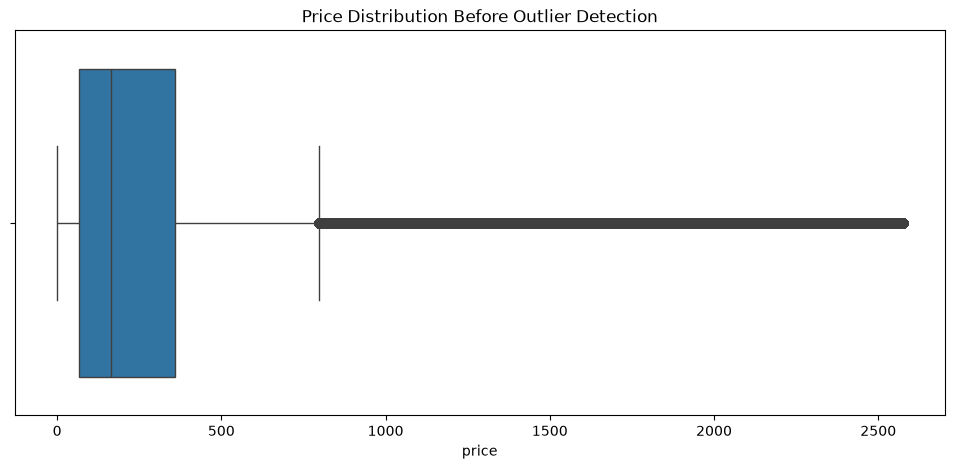

In [25]:
# Price Distribution Before Outlier Detection 

plt.figure(figsize=(12,5))

sns.boxplot(x=df["price"])

plt.title("Price Distribution Before Outlier Detection")

plt.show()

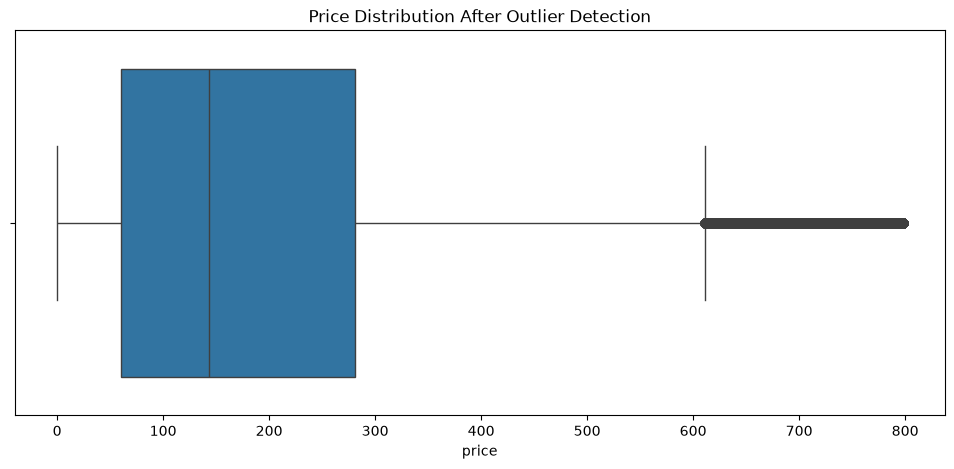

In [26]:
df_price_clean = df[
    (df["price"] >= lower_bound) &
    (df["price"] <= upper_bound)
]

plt.figure(figsize=(12,5))

sns.boxplot(x=df_price_clean["price"])

plt.title("Price Distribution After Outlier Detection")

plt.show()

In [27]:
# =====================================================
# Function for Categorical Outlier Analysis
# =====================================================

def categorical_outlier_analysis(data, column):

    summary = (
        data[column]
        .value_counts(dropna=False)
        .reset_index()
    )

    summary.columns = [column, "Frequency"]

    summary["Percentage"] = (
        summary["Frequency"] /
        summary["Frequency"].sum() * 100
    )

    Q1 = summary["Frequency"].quantile(0.25)
    Q3 = summary["Frequency"].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    summary["Status"] = "Normal"

    summary.loc[
        summary["Frequency"] < lower,
        "Status"
    ] = "Rare Category"

    summary.loc[
        summary["Frequency"] > upper,
        "Status"
    ] = "Dominant Category"

    print("="*60)
    print(column.upper())
    print("="*60)

    print(f"Q1 : {Q1:.2f}")
    print(f"Q3 : {Q3:.2f}")
    print(f"IQR : {IQR:.2f}")

    display(summary.head(15))

    plt.figure(figsize=(12,5))

    sns.boxplot(
        x=summary["Frequency"]
    )

    plt.title(f"{column} Frequency Distribution")

    plt.show()

    return summary

BRAND
Q1 : 49.00
Q3 : 2025.00
IQR : 1976.00


,brand,Frequency,Percentage,Status
0,unknown,6116198,14.418689,Dominant Category
1,samsung,5271172,12.426575,Dominant Category
2,apple,4116981,9.705616,Dominant Category
3,xiaomi,3080998,7.263328,Dominant Category
4,huawei,1109758,2.616210,Dominant Category
5,lucente,655818,1.546064,Dominant Category
6,lg,561883,1.324616,Dominant Category
7,bosch,556877,1.312815,Dominant Category
8,oppo,482131,1.136604,Dominant Category
9,sony,456429,1.076013,Dominant Category


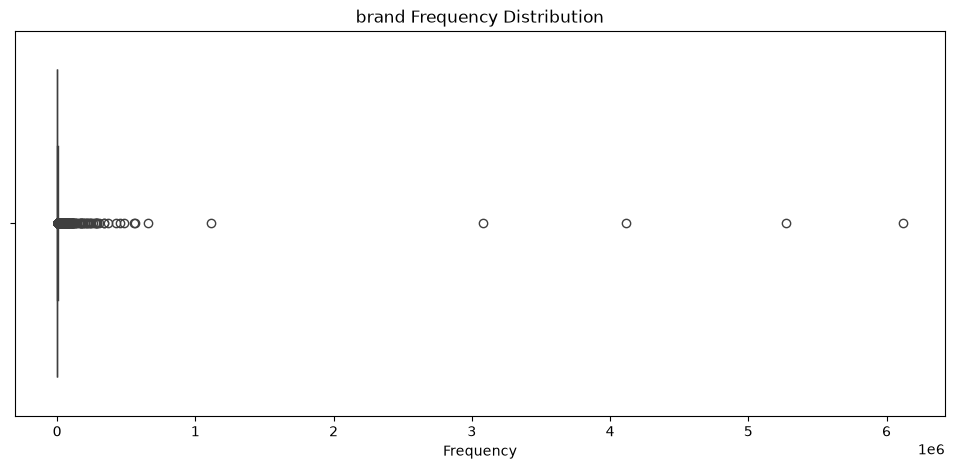

In [28]:
brand_summary = categorical_outlier_analysis(
    df,
    "brand"
)

CATEGORY_CODE
Q1 : 13471.00
Q3 : 151928.50
IQR : 138457.50


,category_code,Frequency,Percentage,Status
0,unknown,13512262,31.854611,Dominant Category
1,electronics.smartphone,11488634,27.083989,Dominant Category
2,electronics.clocks,1310597,3.089679,Dominant Category
3,computers.notebook,1137129,2.680736,Dominant Category
4,electronics.video.tv,1112512,2.622702,Dominant Category
5,electronics.audio.headphone,1098865,2.590530,Dominant Category
6,appliances.kitchen.refrigerators,887278,2.091722,Dominant Category
7,appliances.kitchen.washer,868253,2.046871,Dominant Category
8,appliances.environment.vacuum,801100,1.888561,Dominant Category
9,apparel.shoes,763892,1.800844,Dominant Category


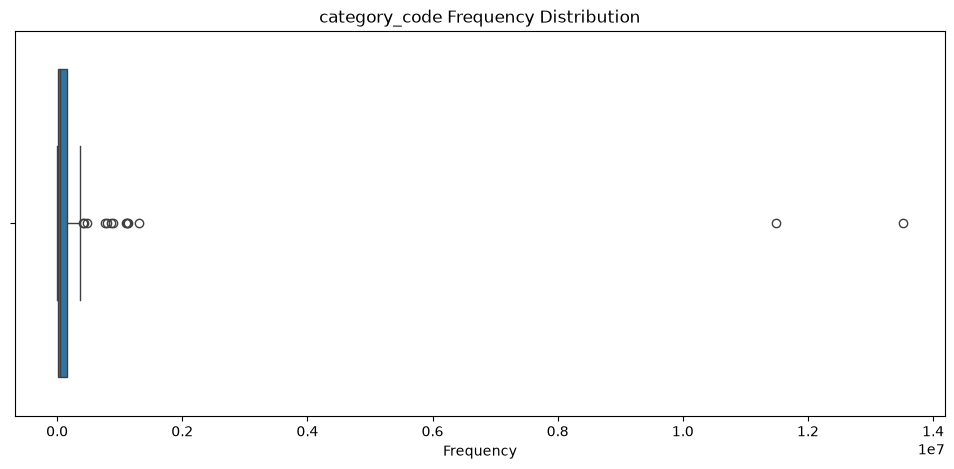

In [29]:
category_summary = categorical_outlier_analysis(
    df,
    "category_code"
)

EVENT_TYPE
Q1 : 820608.00
Q3 : 20837885.50
IQR : 20017277.50


,event_type,Frequency,Percentage,Status
0,view,40777328,96.130900,Normal
1,cart,898443,2.118043,Normal
2,purchase,742773,1.751057,Normal


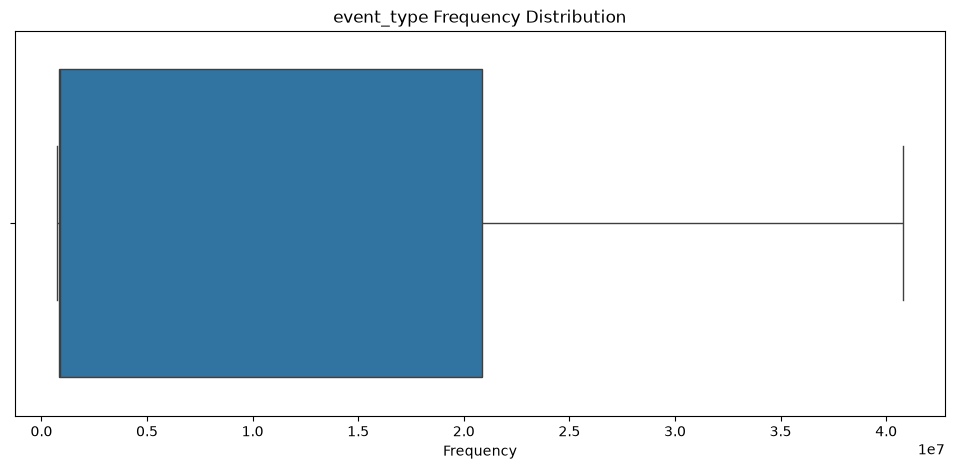

In [30]:
event_summary = categorical_outlier_analysis(
    df,
    "event_type"
)

In [31]:
# Summary of Outlier Analysis

summary = pd.DataFrame({

    "Column":[
        "Price",
        "Brand",
        "Category",
        "Event Type"
    ],

    "Method":[
        "IQR",
        "Frequency + IQR",
        "Frequency + IQR",
        "Frequency + IQR"
    ],

    "Action":[
        "Reviewed",
        "Reviewed",
        "Reviewed",
        "Reviewed"
    ]

})

display(summary)

,Column,Method,Action
0,Price,IQR,Reviewed
1,Brand,Frequency + IQR,Reviewed
2,Category,Frequency + IQR,Reviewed
3,Event Type,Frequency + IQR,Reviewed


## Exploratory Data Analysis

### EDA scope
Pada bagian ini, analisis dibagi menjadi:
- Univariate Analysis
- Bivariate Analysis
- Multivariate Analysis
- Time Series Analysis
- Heatmap bisnis untuk pola aktivitas pelanggan


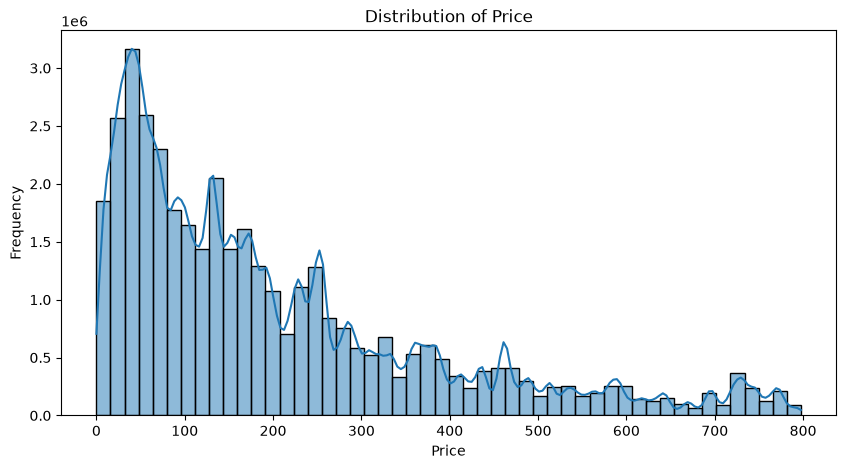

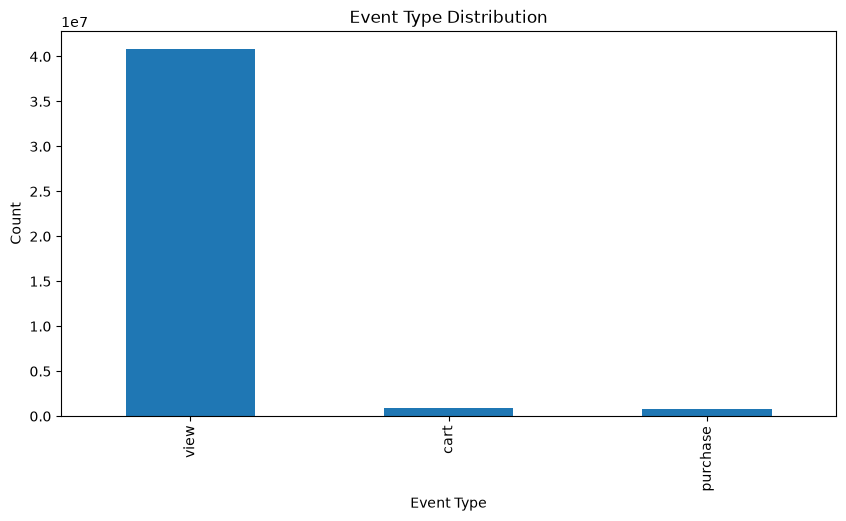

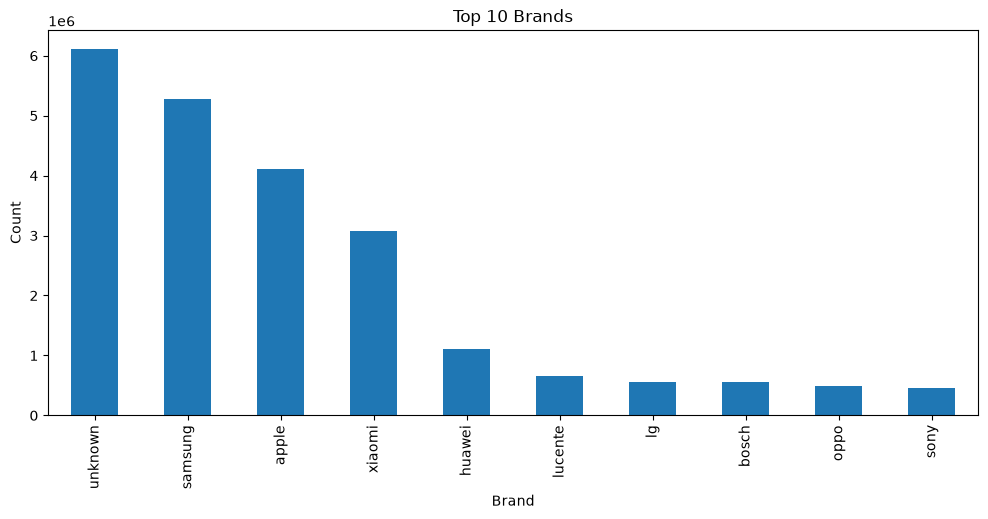

In [32]:

# Univariate Analysis
plt.figure(figsize=(10, 5))
sns.histplot(df_price_clean['price'], bins=50, kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 5))
df['event_type'].value_counts().plot(kind='bar')
plt.title('Event Type Distribution')
plt.xlabel('Event Type')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(12, 5))
df['brand'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Brands')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.show()


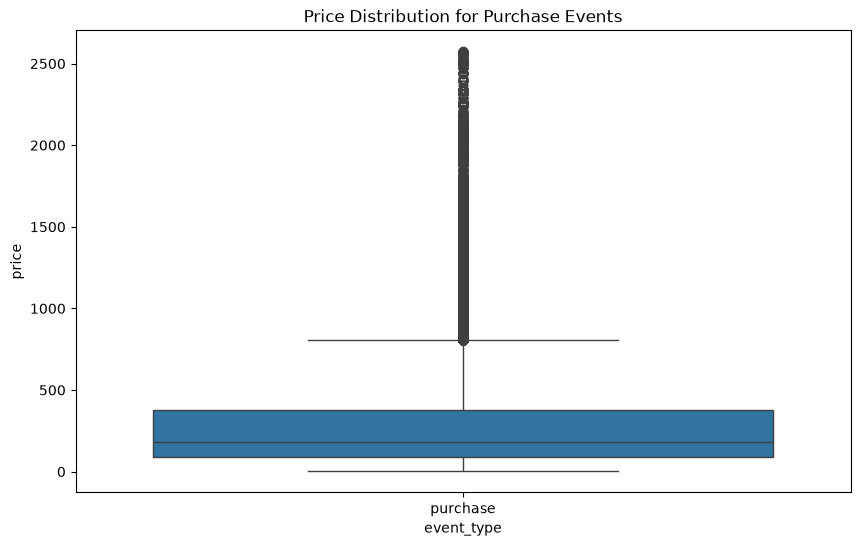

,count,sum,mean
category_code,,,
electronics.smartphone,337979,1.570339e+08,464.626246
unknown,173411,2.292217e+07,132.184031
computers.notebook,15588,8.978883e+06,576.012537
electronics.video.tv,21561,8.422119e+06,390.618217
electronics.clocks,17903,4.817089e+06,269.066025
appliances.kitchen.washer,16146,4.658223e+06,288.506346
appliances.kitchen.refrigerators,11218,3.830077e+06,341.422447
electronics.audio.headphone,30501,3.538807e+06,116.022661
appliances.environment.vacuum,12378,1.716425e+06,138.667427


In [33]:
# Bivariate Analysis
purchase_df = df[df['event_type'] == 'purchase'].copy()

plt.figure(figsize=(10, 6))
sns.boxplot(data=purchase_df, x='event_type', y='price')
plt.title('Price Distribution for Purchase Events')
plt.show()

category_purchase = (
    purchase_df.groupby('category_code')['price']
    .agg(['count', 'sum', 'mean'])
    .sort_values('sum', ascending=False)
    .head(10)
)
display(category_purchase)


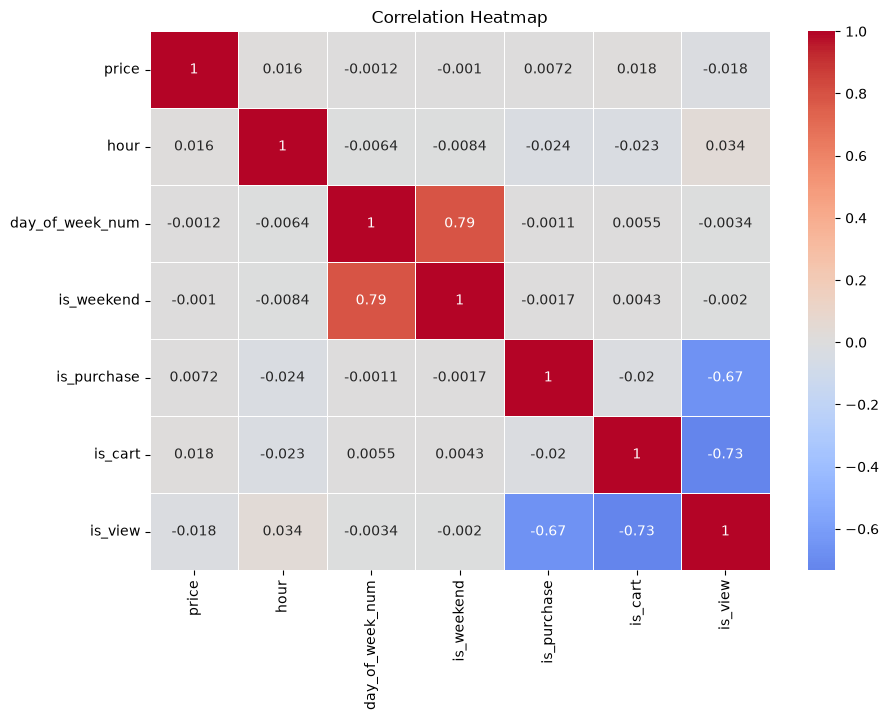

In [34]:
# Multivariate Analysis - Correlation Heatmap
df_corr = df.copy()
df_corr['event_time'] = pd.to_datetime(df_corr['event_time'], errors='coerce', utc=True)
df_corr['day_of_week_num'] = df_corr['event_time'].dt.dayofweek
df_corr['is_weekend'] = df_corr['day_of_week_num'].isin([5, 6]).astype(int)
df_corr['is_purchase'] = (df_corr['event_type'] == 'purchase').astype(int)
df_corr['is_cart'] = (df_corr['event_type'] == 'cart').astype(int)
df_corr['is_view'] = (df_corr['event_type'] == 'view').astype(int)

corr_cols = ['price', 'hour', 'day_of_week_num', 'is_weekend', 'is_purchase', 'is_cart', 'is_view']
corr_matrix = df_corr[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


## Time Series Analysis

In [35]:
# Ensure datetime and create time-based features
df['event_time'] = pd.to_datetime(df['event_time'], utc=True, errors='coerce')
df['date'] = df['event_time'].dt.date
df['hour'] = df['event_time'].dt.hour
df['day_name'] = df['event_time'].dt.day_name()
df['day_of_week_num'] = df['event_time'].dt.dayofweek
df['is_weekend'] = df['day_of_week_num'].isin([5, 6]).astype(int)
df['is_purchase'] = (df['event_type'] == 'purchase').astype(int)


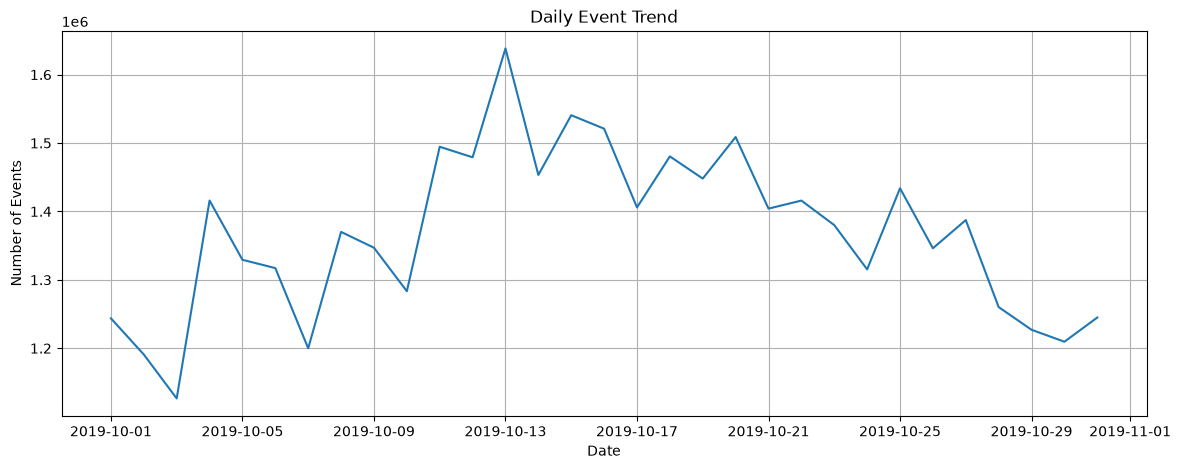

In [36]:
# Daily event trend
daily_events = df.groupby('date').size().reset_index(name='total_events')
daily_events['date'] = pd.to_datetime(daily_events['date'])

plt.figure(figsize=(14, 5))
plt.plot(daily_events['date'], daily_events['total_events'])
plt.title('Daily Event Trend')
plt.xlabel('Date')
plt.ylabel('Number of Events')
plt.grid(True)
plt.show()


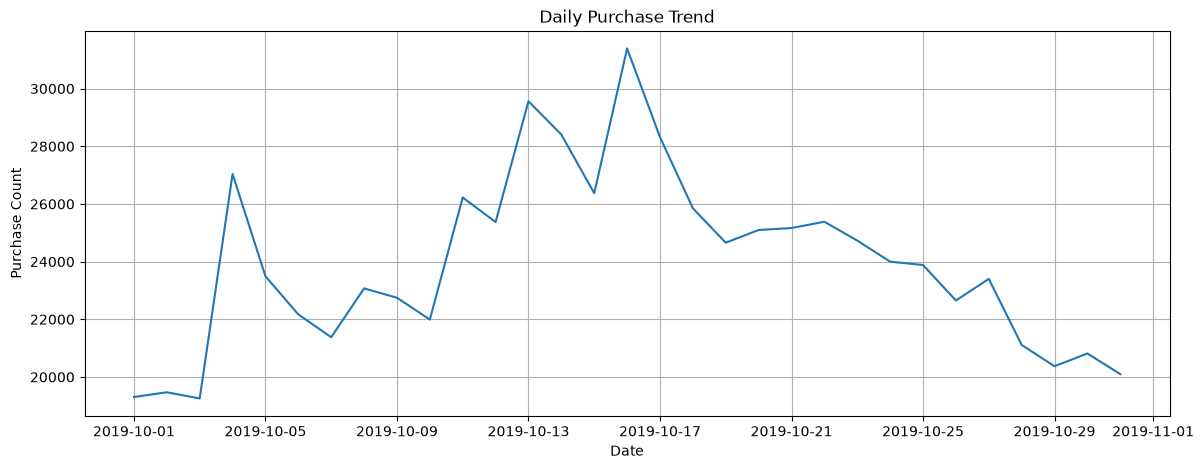

In [37]:
# Daily purchase trend
daily_purchase = (
    df[df['event_type'] == 'purchase']
    .groupby('date')
    .size()
    .reset_index(name='purchase_count')
)
daily_purchase['date'] = pd.to_datetime(daily_purchase['date'])

plt.figure(figsize=(14, 5))
plt.plot(daily_purchase['date'], daily_purchase['purchase_count'])
plt.title('Daily Purchase Trend')
plt.xlabel('Date')
plt.ylabel('Purchase Count')
plt.grid(True)
plt.show()


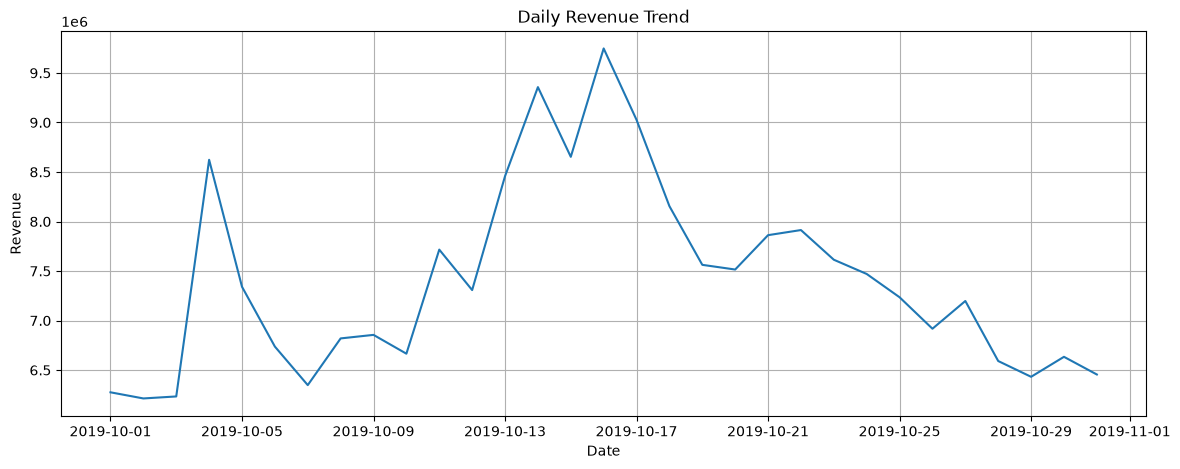

In [38]:
# Daily revenue trend
daily_revenue = (
    df[df['event_type'] == 'purchase']
    .groupby('date')['price']
    .sum()
    .reset_index(name='revenue')
)
daily_revenue['date'] = pd.to_datetime(daily_revenue['date'])

plt.figure(figsize=(14, 5))
plt.plot(daily_revenue['date'], daily_revenue['revenue'])
plt.title('Daily Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()


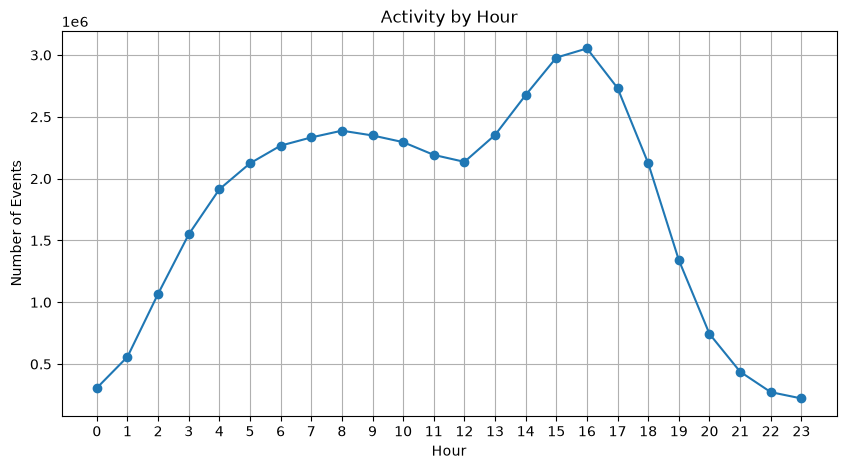

In [39]:
# Hourly activity
hourly_activity = df.groupby('hour').size().reset_index(name='events')

plt.figure(figsize=(10, 5))
plt.plot(hourly_activity['hour'], hourly_activity['events'], marker='o')
plt.xticks(range(24))
plt.title('Activity by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Events')
plt.grid(True)
plt.show()


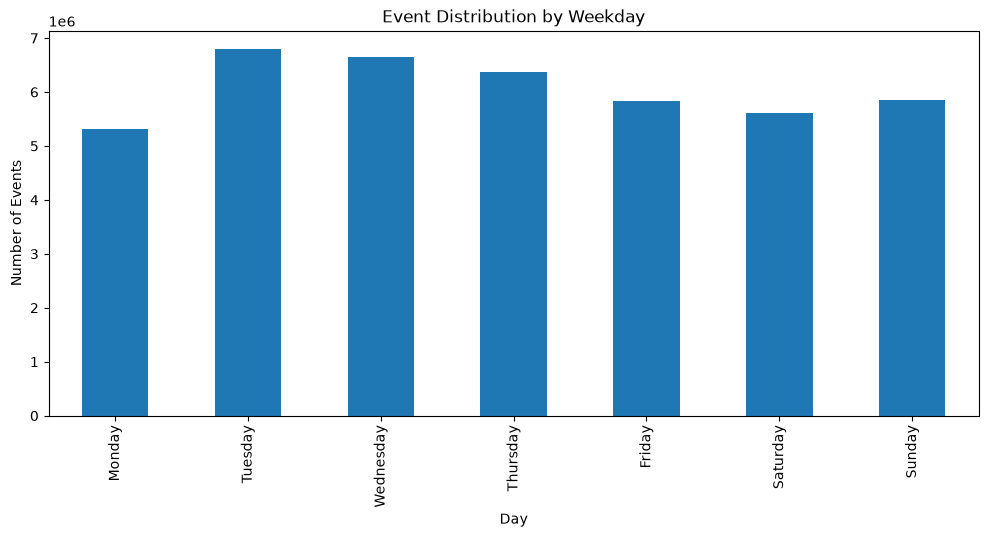

In [40]:
# Weekday analysis
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = (
    df.groupby('day_name').size().reindex(weekday_order)
)

plt.figure(figsize=(12, 5))
weekday_counts.plot(kind='bar')
plt.title('Event Distribution by Weekday')
plt.xlabel('Day')
plt.ylabel('Number of Events')
plt.show()


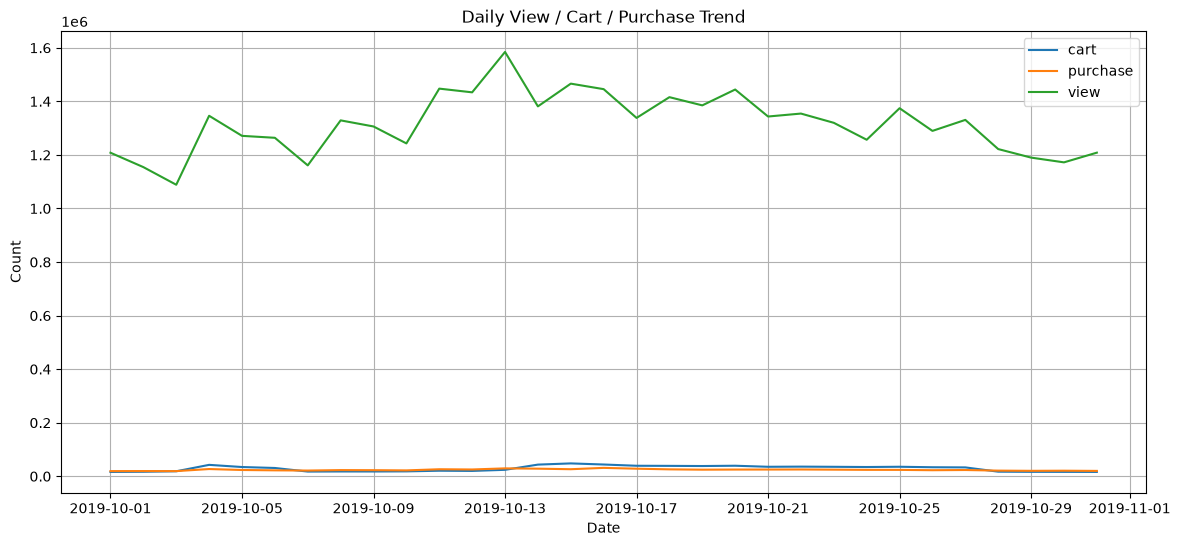

In [41]:
# View / Cart / Purchase trend by date
event_trend = (
    df.groupby(['date', 'event_type'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
event_trend.index = pd.to_datetime(event_trend.index)

plt.figure(figsize=(14, 6))
for col in event_trend.columns:
    plt.plot(event_trend.index, event_trend[col], label=col)
plt.title('Daily View / Cart / Purchase Trend')
plt.xlabel('Date')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.show()


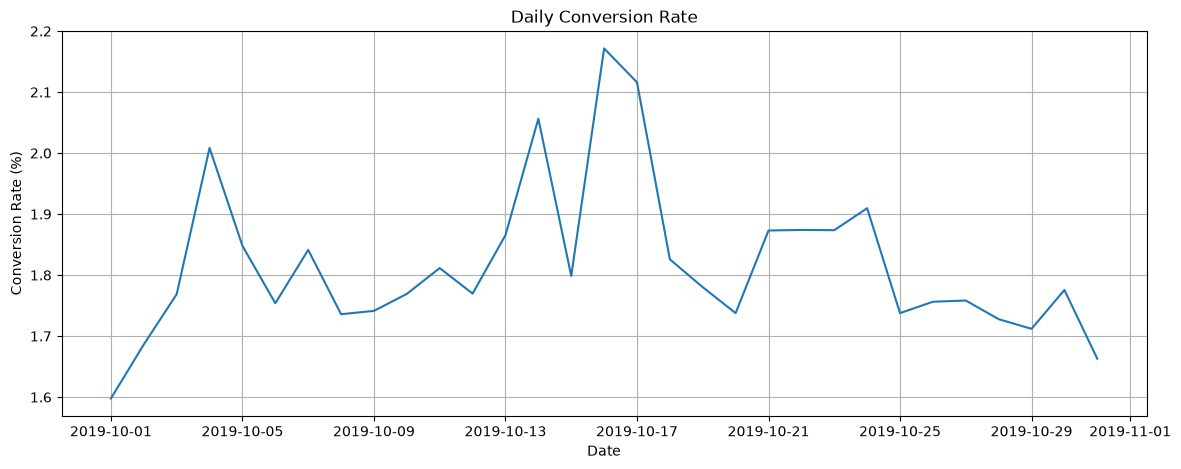

In [42]:
# Daily conversion rate
daily_summary = (
    df.groupby(['date', 'event_type'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
daily_summary.index = pd.to_datetime(daily_summary.index)
daily_summary['conversion_rate'] = daily_summary.get('purchase', 0) / daily_summary.get('view', 1) * 100

plt.figure(figsize=(14, 5))
plt.plot(daily_summary.index, daily_summary['conversion_rate'])
plt.title('Daily Conversion Rate')
plt.xlabel('Date')
plt.ylabel('Conversion Rate (%)')
plt.grid(True)
plt.show()


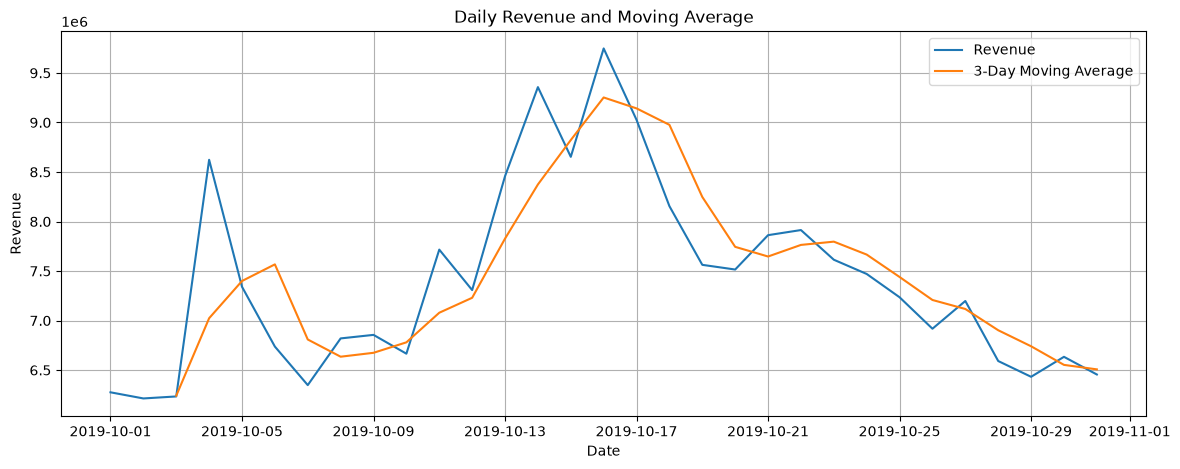

In [43]:
# 3-day moving average for revenue
daily_revenue_ma = daily_revenue.sort_values('date').copy()
daily_revenue_ma['ma_3'] = daily_revenue_ma['revenue'].rolling(window=3).mean()

plt.figure(figsize=(14, 5))
plt.plot(daily_revenue_ma['date'], daily_revenue_ma['revenue'], label='Revenue')
plt.plot(daily_revenue_ma['date'], daily_revenue_ma['ma_3'], label='3-Day Moving Average')
plt.title('Daily Revenue and Moving Average')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)
plt.show()


Exponential Moving Average (EMA) digunakan untuk memberikan bobot yang lebih besar pada data terbaru sehingga mampu menangkap perubahan tren revenue lebih cepat dibandingkan Simple Moving Average (SMA).

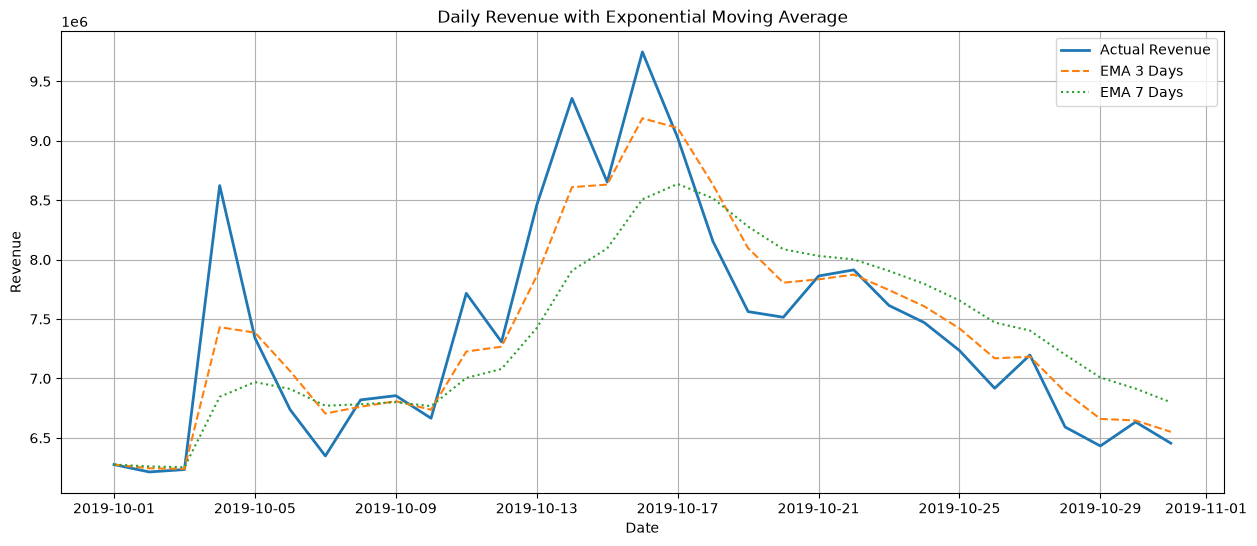

In [44]:
# =====================================================
# Exponential Moving Average (EMA)
# =====================================================

daily_revenue_ema = daily_revenue.copy()

daily_revenue_ema = daily_revenue_ema.sort_values("date")

daily_revenue_ema["EMA_3"] = (
    daily_revenue_ema["revenue"]
    .ewm(span=3, adjust=False)
    .mean()
)

daily_revenue_ema["EMA_7"] = (
    daily_revenue_ema["revenue"]
    .ewm(span=7, adjust=False)
    .mean()
)

plt.figure(figsize=(15,6))

plt.plot(
    daily_revenue_ema["date"],
    daily_revenue_ema["revenue"],
    label="Actual Revenue",
    linewidth=2
)

plt.plot(
    daily_revenue_ema["date"],
    daily_revenue_ema["EMA_3"],
    label="EMA 3 Days",
    linestyle="--"
)

plt.plot(
    daily_revenue_ema["date"],
    daily_revenue_ema["EMA_7"],
    label="EMA 7 Days",
    linestyle=":"
)

plt.title("Daily Revenue with Exponential Moving Average")

plt.xlabel("Date")

plt.ylabel("Revenue")

plt.grid(True)

plt.legend()

plt.show()

Holt-Winters Exponential Smoothing digunakan untuk melakukan forecasting revenue jangka pendek berdasarkan pola historis, dikarenakan dataset hanya mencakup satu bulan, model menggunakan komponen trend tanpa seasonality.

c:\Users\MSI1\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


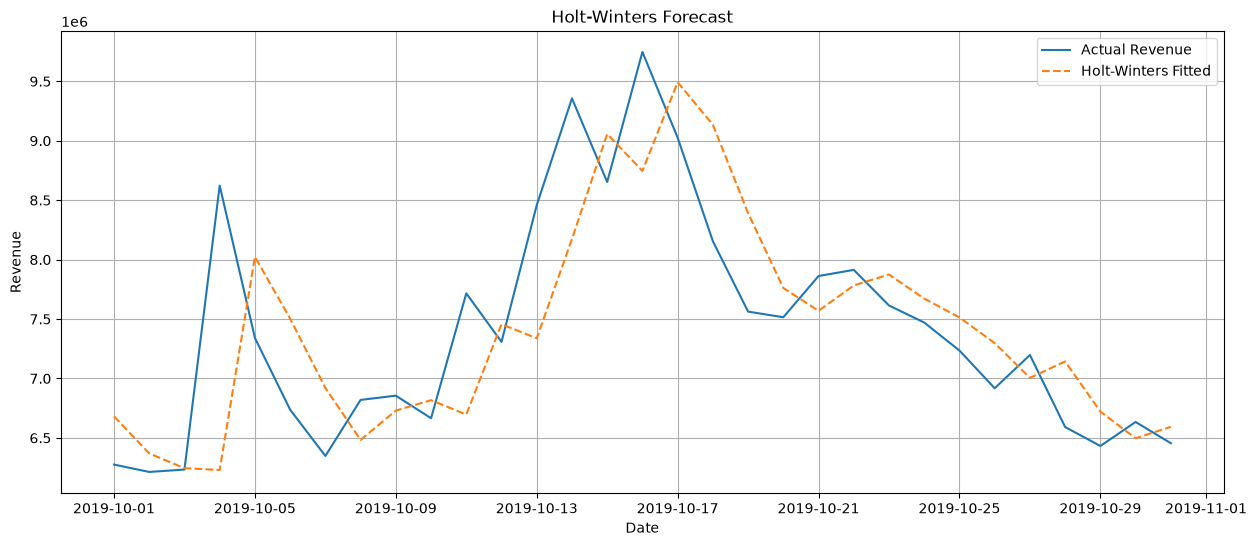

In [45]:
# =====================================================
# Holt-Winters Forecast
# =====================================================

ts = (
    daily_revenue
    .sort_values("date")
    .copy()
)

ts["date"] = pd.to_datetime(ts["date"])

ts = ts.set_index("date")

model = ExponentialSmoothing(
    ts["revenue"],
    trend="add",
    seasonal=None
)

fit = model.fit()

ts["forecast"] = fit.fittedvalues

# Visualization

plt.figure(figsize=(15,6))

plt.plot(
    ts.index,
    ts["revenue"],
    label="Actual Revenue"
)

plt.plot(
    ts.index,
    ts["forecast"],
    label="Holt-Winters Fitted",
    linestyle="--"
)

plt.title("Holt-Winters Forecast")

plt.xlabel("Date")

plt.ylabel("Revenue")

plt.grid(True)

plt.legend()

plt.show()

Berdasarkan visualisasi di atas, model Holt-Winters mampu mengikuti pola perubahan revenue harian dengan cukup baik. Nilai fitted mengikuti arah tren aktual, baik pada periode kenaikan maupun penurunan revenue. 

Namun demikian, model menghasilkan kurva yang lebih halus sehingga tidak sepenuhnya menangkap lonjakan revenue yang terjadi pada beberapa hari tertentu. Hal ini merupakan karakteristik umum dari metode Exponential Smoothing yang lebih menekankan kestabilan tren dibandingkan mengikuti fluktuasi jangka pendek secara langsung.

,Date,Forecast Revenue
0,2019-11-01,6.482802e+06
1,2019-11-02,6.476045e+06
2,2019-11-03,6.469289e+06
3,2019-11-04,6.462532e+06
4,2019-11-05,6.455776e+06
5,2019-11-06,6.449019e+06
6,2019-11-07,6.442263e+06


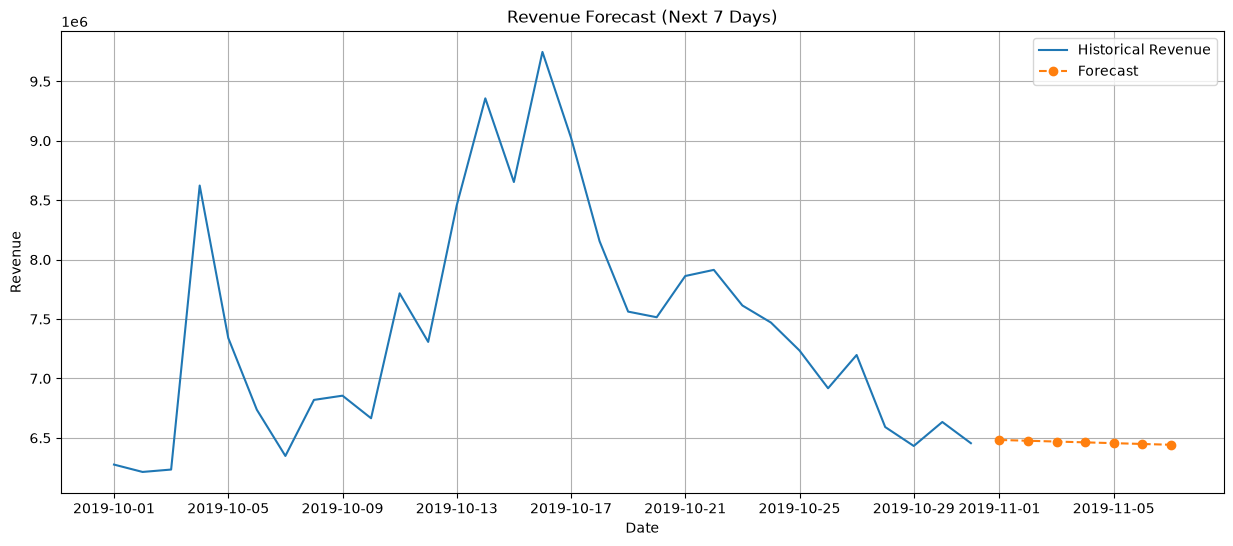

In [46]:
# 7 Days Forecast

forecast = fit.forecast(7)

future_dates = pd.date_range(
    ts.index[-1] + pd.Timedelta(days=1),
    periods=7
)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast Revenue": forecast.values
})

display(forecast_df)

# Visualization

plt.figure(figsize=(15,6))

plt.plot(
    ts.index,
    ts["revenue"],
    label="Historical Revenue"
)

plt.plot(
    future_dates,
    forecast,
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.title("Revenue Forecast (Next 7 Days)")

plt.xlabel("Date")

plt.ylabel("Revenue")

plt.grid(True)

plt.legend()

plt.show()

Forecast 7 hari ke depan hampir berupa garis datar di sekitar 6,5 juta.

Artinya model memperkirakan bahwa:
- tidak ada kenaikan besar,
- tidak ada penurunan tajam,
- revenue diperkirakan berada pada level yang relatif stabil.

In [47]:
# =====================================================
# MAE, RMSE, MAPE Calculation
# =====================================================

from sklearn.metrics import (mean_absolute_error, mean_squared_error, mean_absolute_percentage_error)

mae = mean_absolute_error(ts["revenue"],ts["forecast"])

rmse = np.sqrt(mean_squared_error(ts["revenue"],ts["forecast"]))

mape = mean_absolute_percentage_error(ts["revenue"],ts["forecast"])

print(f"MAE  : {mae:,.2f} \nRata-rata kesalahan prediksi sekitar 511 ribu revenue per hari.\n")
print(f"RMSE : {rmse:,.2f} \nKesalahan yang lebih sensitif terhadap error besar sekitar 698 ribu revenue per hari.\n")
print(f"MAPE : {mape*100:.2f}% \nRata-rata prediksi meleset {mape*100:.2f}% dari nilai aktual.")

MAE  : 511,302.41 
Rata-rata kesalahan prediksi sekitar 511 ribu revenue per hari.

RMSE : 699,073.96 
Kesalahan yang lebih sensitif terhadap error besar sekitar 698 ribu revenue per hari.

MAPE : 6.57% 
Rata-rata prediksi meleset 6.57% dari nilai aktual.


In [48]:
# Growth rate
daily_revenue_ma['growth_rate_pct'] = daily_revenue_ma['revenue'].pct_change() * 100
display(daily_revenue_ma[['date', 'revenue', 'ma_3', 'growth_rate_pct']].head(10))


,date,revenue,ma_3,growth_rate_pct
0,2019-10-01,6275579.06,NaN,NaN
1,2019-10-02,6213628.53,NaN,-0.987168
2,2019-10-03,6233782.98,6.240997e+06,0.324359
3,2019-10-04,8623058.19,7.023490e+06,38.327854
4,2019-10-05,7341094.46,7.399312e+06,-14.866695
5,2019-10-06,6737258.17,7.567137e+06,-8.225426
6,2019-10-07,6348189.06,6.808847e+06,-5.774888
7,2019-10-08,6819701.26,6.635049e+06,7.427507
8,2019-10-09,6855326.05,6.674405e+06,0.522381
9,2019-10-10,6665413.21,6.780147e+06,-2.770296


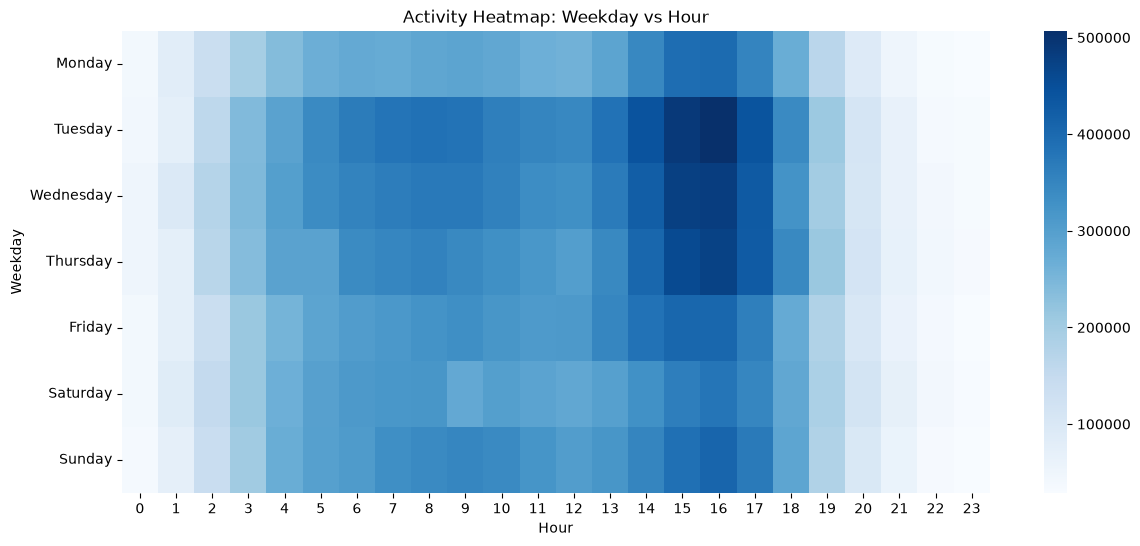

In [49]:
# Business heatmap: weekday x hour activity
heatmap_activity = (
    df.pivot_table(index='day_name', columns='hour', values='event_type', aggfunc='count', fill_value=0)
    .reindex(weekday_order)
)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_activity, cmap='Blues')
plt.title('Activity Heatmap: Weekday vs Hour')
plt.xlabel('Hour')
plt.ylabel('Weekday')
plt.show()


## Hypothesis Testing

Tahap ini bertujuan untuk memvalidasi apakah hubungan yang ditemukan selama Exploratory Data Analysis (EDA) memiliki signifikansi secara statistik.

Pada bagian ini digunakan **Chi-Square Test of Independence** untuk menguji hubungan antara variabel kategorikal.

In [50]:
# =========================
# Chi-Square Test
# Brand vs Event Type
# =========================

# Ambil top 15 brand, sisanya jadi "Other"
top_brands = df["brand"].value_counts().head(15).index

brand_group = df["brand"].where(df["brand"].isin(top_brands),"Other")

contingency_table = pd.crosstab(brand_group,df["event_type"])

display(contingency_table)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic : {chi2:.4f}")
print(f"p-value              : {p:.6f}")
print(f"Degrees of freedom   : {dof}")

# Cramer's V
n = contingency_table.to_numpy().sum()
r, c = contingency_table.shape
cramers_v = np.sqrt(chi2 / (n * (min(r-1, c-1))))
print(f"Cramer's V           : {cramers_v:.4f}")

event_type,cart,purchase,view
brand,,,
Other,165684,213278,17854324
acer,9153,6880,411849
apple,203757,142858,3770366
artel,6213,6123,325630
bosch,6965,5705,544207
cordiant,5513,10551,351981
hp,2668,3596,298869
huawei,40753,23499,1045506
lenovo,2820,4578,330589


Chi-square statistic : 972046.8775
p-value              : 0.000000
Degrees of freedom   : 30
Cramer's V           : 0.1070


Hasil uji Chi-Square menghasilkan p-value < 0,001, sehingga hipotesis nol ditolak. Hal ini menunjukkan bahwa terdapat hubungan yang signifikan antara Brand dan Event Type.

Namun demikian, nilai Cramer's V sebesar 0,107 mengindikasikan bahwa kekuatan hubungan tersebut tergolong lemah. Dengan kata lain, meskipun pola interaksi pelanggan berbeda pada setiap brand, pengaruh brand terhadap jenis interaksi pelanggan relatif kecil.

## Export Dataset

In [51]:
# Export cleaned/analysis-ready data
output_file = 'ecommerce_clean.csv'
df.to_csv(output_file, index=False)
print(f'Saved: {output_file}')


Saved: ecommerce_clean.csv
